# Working with the RGI and prepare glaciers for a run

The glacier outlines obtained from the [Randolph Glacier Inventory](https://www.glims.org/RGI/) are the reference dataset for global and regional applications in OGGM. The current version supported by is V6, and OGGM ships with a slightly modified version which we called `62`. OGGM also supports RGI 7, but not yet for full modelling workflows.

**Tags:** beginner, glacier-directory, workflow, RGI

## Find out the ID of a glacier

If there is a glacier you like, and you would like to know their RGI6 or RGI7 id, we recommend the [GLIMS glacier viewer](https://www.glims.org/maps/glims). To find the RGI6 ID, you'll need to tick the "RGI6" box in the map layers, then click on the glacier of your choice as illustrated below.

![](../../img/show_viewer.gif)

## Download the glacier outlines 

 To download this version, simply do: 

In [1]:
# this might take a couple of minutes!
from oggm import utils
utils.get_rgi_dir(version='62')  # path to the data after download - for RGI7, you can use '70G' (for the glacier product) or '70C' (for the glacier complex product)

  0% of 401.9 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
 12% of 401.9 MiB |##                    | Elapsed Time: 0:00:15 ETA:   0:01:43
 23% of 401.9 MiB |#####                 | Elapsed Time: 0:00:30 ETA:   0:01:38
 31% of 401.9 MiB |######                | Elapsed Time: 0:00:45 ETA:   0:01:40
 37% of 401.9 MiB |########              | Elapsed Time: 0:01:00 ETA:   0:01:41
 44% of 401.9 MiB |#########             | Elapsed Time: 0:01:15 ETA:   0:01:34
 54% of 401.9 MiB |###########           | Elapsed Time: 0:01:30 ETA:   0:01:16
 61% of 401.9 MiB |#############         | Elapsed Time: 0:01:45 ETA:   0:01:04
 69% of 401.9 MiB |###############       | Elapsed Time: 0:02:00 ETA:   0:00:52
 77% of 401.9 MiB |################      | Elapsed Time: 0:02:15 ETA:   0:00:39
 84% of 401.9 MiB |##################    | Elapsed Time: 0:02:30 ETA:   0:00:27
 90% of 401.9 MiB |###################   | Elapsed Time: 0:02:46 ETA:   0:00:18
 93% of 401.9 MiB |#################### 

'/home/connor/OGGM/rgi/RGIV62'

## Access a region file

The RGI is divided in 19 regions (and many more sub-regions, not plotted here):

![rgi-map](https://www.researchgate.net/profile/Tobias_Bolch/publication/264125572/figure/fig1/AS:295867740377088@1447551774164/First-order-regions-of-the-RGI-with-glaciers-shown-in-red-Region-numbers-are-those-of.png)
*Source: [the RGI consortium](http://www.glims.org/RGI/randolph60.html)*

In [2]:
fr = utils.get_rgi_region_file(11, version='62')  # Central Europe

The RGI region files are [shapefiles](https://en.wikipedia.org/wiki/Shapefile), a vector format commonly used in GIS applications. The library of choice to read shapefiles in python is [geopandas](http://geopandas.org/):

In [3]:
import geopandas as gpd
gdf = gpd.read_file(fr)

## The RGI files and their attributes 

The `gdf` variable is a `GeoDataFrame`, i.e. you can use most of the tools you know from pandas' `DataFrames`:

In [4]:
len(gdf)

3927

In [5]:
gdf.head()

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Lmax,Status,Connect,Form,TermType,Surging,Linkages,Name,check_geom,geometry
0,RGI60-11.00001,G013599E47495N,20030799,20030999,13.5987,47.4949,11,1,0.122,2191,...,461,0,0,0,0,9,9,None,None,"POLYGON ((13.60035 47.4933, 13.59995 47.49332,..."
1,RGI60-11.00002,G013614E47485N,20030799,20030999,13.6135,47.4845,11,1,2.292,2203,...,1853,0,0,0,0,9,9,None,None,"POLYGON ((13.60638 47.47578, 13.60599 47.47579..."
2,RGI60-11.00003,G013596E47484N,20030799,20030999,13.5960,47.4835,11,1,0.851,2280,...,1140,0,0,0,0,9,9,None,None,"POLYGON ((13.59765 47.47613, 13.59726 47.47614..."
3,RGI60-11.00004,G013583E47481N,20030799,20030999,13.5829,47.4807,11,1,0.053,2319,...,382,0,0,0,0,9,9,None,None,"POLYGON ((13.58283 47.47969, 13.58243 47.47971..."
4,RGI60-11.00005,G013603E47477N,20030799,20030999,13.6026,47.4774,11,1,0.057,2656,...,202,0,0,0,0,9,9,None,None,"POLYGON ((13.60076 47.47519, 13.60036 47.47521..."


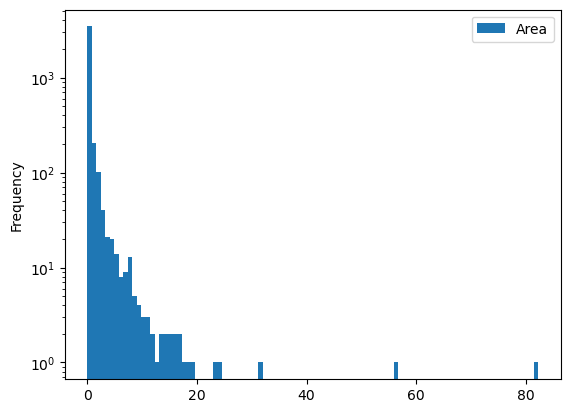

In [6]:
gdf[['Area']].plot(kind='hist', bins=100, logy=True);

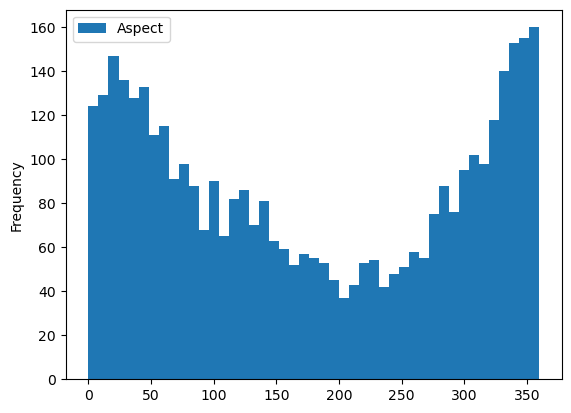

In [7]:
gdf[['Aspect']].plot(kind='hist', bins=45);

## Selecting glaciers per attribute

You may want to select all glaciers in the subregion 2 (Pyrenees):

In [8]:
gdf_sel = gdf.loc[gdf.O2Region == '2']

In [9]:
'Glacier area in the Pyrenees: {} km2'.format(gdf_sel.Area.sum())

'Glacier area in the Pyrenees: 3.183 km2'

## Selecting glaciers in a basin 

Let's use a file shipped with OGGM for a start: 

In [10]:
path = utils.get_demo_file('rofental_hydrosheds.shp')
basin = gpd.read_file(path)

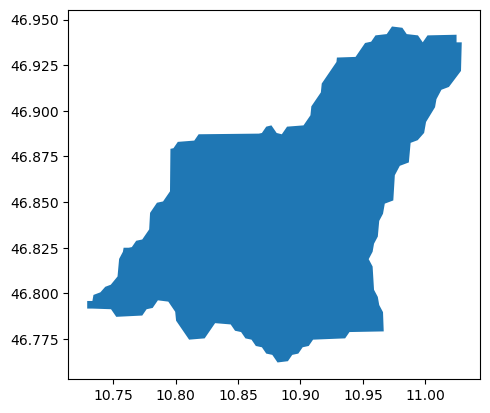

In [11]:
basin.plot();

And select all glaciers within this shape:

In [12]:
import shapely.geometry as shpg
in_bas = [basin.geometry.contains(shpg.Point(x, y))[0] for
          (x, y) in zip(gdf.CenLon, gdf.CenLat)]
gdf_sel = gdf.loc[in_bas]

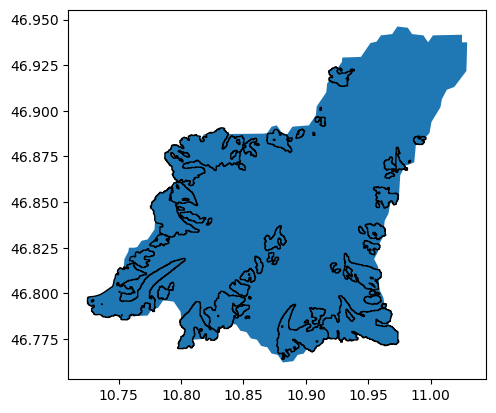

In [13]:
ax = basin.plot();
gdf_sel.plot(ax=ax, edgecolor='k');

## Select glaciers by their ID 

Each glacier in the RGI has a unique ID. It is sometimes difficult to find out which one, but some tools can help you out. For example, the [GLIMS viewer](https://www.glims.org/maps/glims) allows to select glaciers and then see their ID. For example, the Aletsch Glacier in the Swiss Alps:

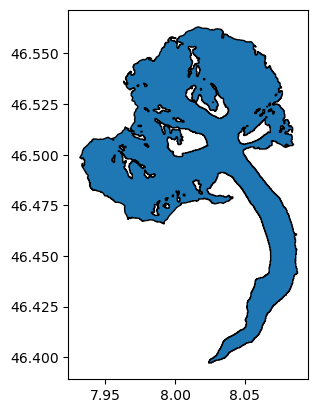

In [14]:
al = utils.get_rgi_glacier_entities(['RGI60-11.01450'], version='62')
al.plot(edgecolor='k');

## Use the RGI files to start an OGGM run 

RGI files can be given as input to OGGM to make a run:

In [15]:
from oggm import cfg, workflow, tasks, DEFAULT_BASE_URL
cfg.initialize(logging_level='WARNING')
cfg.PARAMS['continue_on_error'] = True
cfg.PARAMS['use_multiprocessing'] = True
cfg.PARAMS['border'] = 80
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-Rofental', reset=True)

# Go - get the pre-processed glacier directories
gdirs = workflow.init_glacier_directories(gdf_sel, prepro_base_url=DEFAULT_BASE_URL, from_prepro_level=5)

2026-04-13 10:49:00: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-04-13 10:49:00: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-04-13 10:49:00: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-04-13 10:49:00: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2026-04-13 10:49:00: oggm.cfg: Multiprocessing switched ON after user settings.
2026-04-13 10:49:01: oggm.workflow: init_glacier_directories from prepro level 5 on 54 glaciers.
2026-04-13 10:49:01: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 54 glaciers
  0% of 101.8 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
 71% of 101.8 MiB |###############       | Elapsed Time: 0:00:15 ETA:   0:00:06
100% of 101.8 MiB |######################| Elapsed Time: 0:00:26 Time:  0:00:26


In [16]:
workflow.execute_entity_task(tasks.run_random_climate, gdirs, nyears=100,
                             y0=2009, halfsize=10, output_filesuffix='_2000')
ds2000 = utils.compile_run_output(gdirs, input_filesuffix='_2000')

2026-04-13 10:49:30: oggm.workflow: Execute entity tasks [run_random_climate] on 54 glaciers
2026-04-13 10:49:32: oggm.utils: Applying global task compile_run_output on 54 glaciers
2026-04-13 10:49:32: oggm.utils: Applying compile_run_output on 54 gdirs.


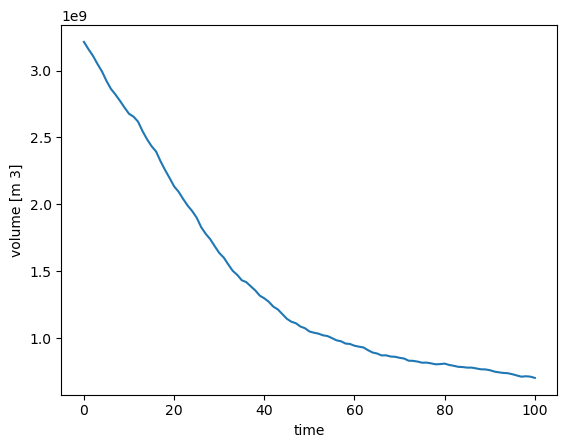

In [17]:
ds2000.sum(dim='rgi_id').volume.plot();

This shows the summed up volume evolution of all glaciers of the Rofental basin.

## What's next?

- look at the [OGGM-Shop documentation](https://docs.oggm.org/en/stable/input-data.html#)
- back to the [table of contents](../welcome.ipynb)